<a href="https://colab.research.google.com/github/melisabozuklu-lang/Numerical-Methods/blob/main/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Guess	Root		Iterations
------------------------------------------
-2.00		-13.351769	4
-1.75		-1.570796	4
-1.50		-1.570796	4
-1.25		-3.926991	4
-1.00		-0.785398	4
-0.75		-0.785398	3
-0.50		5.497787	4
-0.25		-0.000006	15
0.00		0.000000	1
0.25		0.000006	15
0.50		-5.497787	4
0.75		0.785398	3
1.00		0.785398	4
1.25		3.926991	4
1.50		1.570796	4
1.75		1.570796	4
2.00		13.351769	4

Results Table:
    Initial Guess       Root  Iterations  Converged
0           -2.00 -13.351769           4       True
1           -1.75  -1.570796           4       True
2           -1.50  -1.570796           4       True
3           -1.25  -3.926991           4       True
4           -1.00  -0.785398           4       True
5           -0.75  -0.785398           3       True
6           -0.50   5.497787           4       True
7           -0.25  -0.000006          15       True
8            0.00   0.000000           1       True
9            0.25   0.000006          15       True
10           0.50  -5.497787 

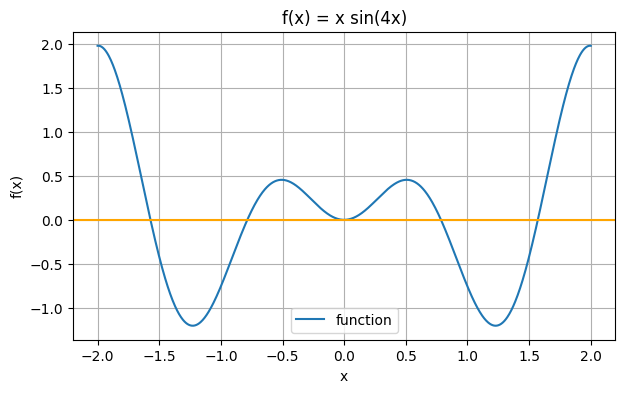

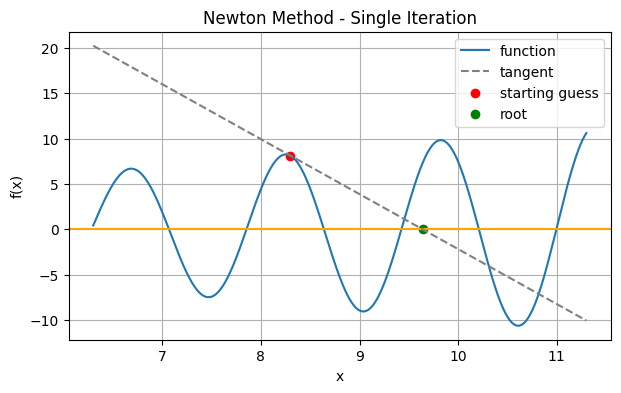

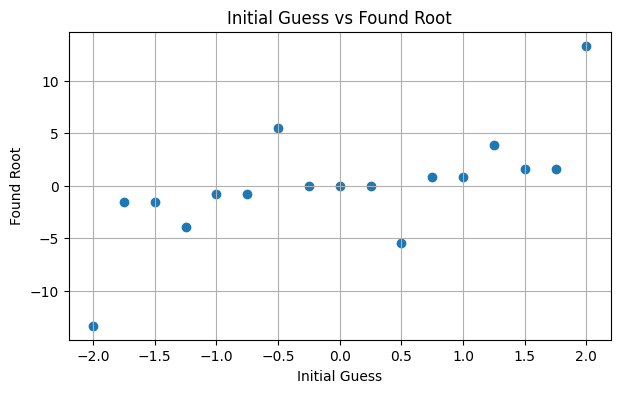

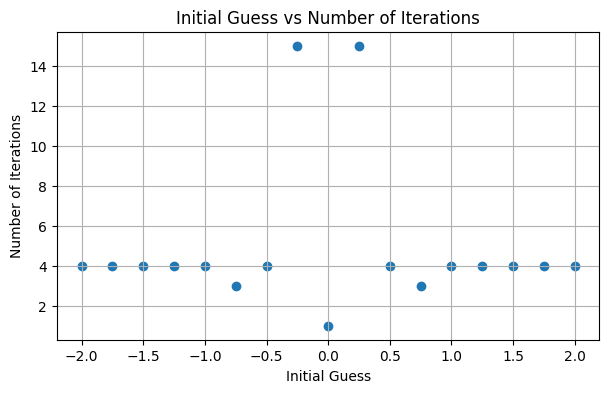

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Function
def f(x):
    return x * np.sin(4*x)

# Derivative
def df(x):
    return np.sin(4*x) + 4*x*np.cos(4*x)

# Newton Method
def newton(x0, TOLX, TOLF, N):

    # If initial guess is already root
    if abs(f(x0)) <= TOLF:
        return x0, 1, True

    for step in range(1, N + 1):

        if abs(df(x0)) < 1e-12:
            return np.nan, step, False

        x1 = x0 - f(x0) / df(x0)

        error_x = abs(x1 - x0)
        error_f = abs(f(x1))

        if error_x <= TOLX and error_f <= TOLF:
            return x1, step, True

        x0 = x1

    return x1, N, False


# Parameters
TOLX = 1e-5
TOLF = 1e-5
N = 20

# Initial guesses
initial_guesses = np.arange(-2, 2.1, 0.25)

roots = []
iterations = []
converged = []

print("Initial Guess\tRoot\t\tIterations")
print("------------------------------------------")

for x0 in initial_guesses:
    root, it, conv = newton(x0, TOLX, TOLF, N)

    roots.append(root)
    iterations.append(it)
    converged.append(conv)

    if conv:
        print(f"{x0:.2f}\t\t{root:.6f}\t{it}")
    else:
        print(f"{x0:.2f}\t\tNo convergence\t{it}")


# Table
results = pd.DataFrame({
    "Initial Guess": initial_guesses,
    "Root": roots,
    "Iterations": iterations,
    "Converged": converged
})

print("\nResults Table:")
print(results)


# -------------------------------------------------
# Figure 1: Function graph
# -------------------------------------------------
x = np.linspace(-2, 2, 1000)

plt.figure(figsize=(7, 4))
plt.plot(x, f(x), label="function")
plt.axhline(0, color="orange")
plt.title("f(x) = x sin(4x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.legend()
plt.show()


# -------------------------------------------------
# Figure 2: Tangent graph (Newton step)
# -------------------------------------------------
x0_tangent = 8.3
x1_tangent = x0_tangent - f(x0_tangent) / df(x0_tangent)

x_plot = np.linspace(6.3, 11.3, 1000)
x_tangent = np.linspace(6.3, 11.3, 200)
y_tangent = df(x0_tangent) * (x_tangent - x0_tangent) + f(x0_tangent)

plt.figure(figsize=(7, 4))
plt.plot(x_plot, f(x_plot), label="function")
plt.axhline(0, color="orange")
plt.plot(x_tangent, y_tangent, "--", color="gray", label="tangent")
plt.scatter(x0_tangent, f(x0_tangent), color="red", label="starting guess")
plt.scatter(x1_tangent, 0, color="green", label="root")
plt.title("Newton Method - Single Iteration")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.legend()
plt.show()


# -------------------------------------------------
# Figure 3: Initial Guess vs Found Root
# -------------------------------------------------
plt.figure(figsize=(7, 4))
plt.scatter(initial_guesses, roots)
plt.title("Initial Guess vs Found Root")
plt.xlabel("Initial Guess")
plt.ylabel("Found Root")
plt.grid()
plt.show()


# -------------------------------------------------
# Figure 4: Initial Guess vs Number of Iterations
# -------------------------------------------------
plt.figure(figsize=(7, 4))
plt.scatter(initial_guesses, iterations)
plt.title("Initial Guess vs Number of Iterations")
plt.xlabel("Initial Guess")
plt.ylabel("Number of Iterations")
plt.grid()
plt.show()